# 03 — Advanced Modeling: Feature Engineering, SMOTE, CatBoost, LightGBM and Error Analysis

## Water Potability Classification

**Цель ноутбука:** улучшить baseline из `02_baseline.ipynb` и выбрать финальную модель.

В этом ноутбуке мы делаем:

1. Повторяем тот же train/test split, что и раньше.
2. Добавляем feature engineering внутри `Pipeline`.
3. Проверяем RandomForest, CatBoost и LightGBM.
4. Проверяем SMOTE для улучшения recall класса `1`.
5. Сравниваем advanced-модели с baseline.
6. Подбираем гиперпараметры лучшего кандидата.
7. Оцениваем финальную модель на test set.
8. Анализируем threshold как exploratory-блок.
9. Делаем error analysis: смотрим, где модель ошибается.

> Важно: все преобразования данных выполняются внутри Pipeline. Это защищает от data leakage.

## 1. Импорт библиотек

Импортируем инструменты для работы с данными, построения pipeline, feature engineering, SMOTE, обучения моделей, cross-validation, tuning и оценки качества.

In [47]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import shap
import joblib

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_recall_curve
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42

## 2. Загрузка данных и train/test split

In [2]:
DATA_PATH = Path("data/raw/water_potability.csv")

df = pd.read_csv(DATA_PATH)

target_col = "Potability"

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

split_check = pd.DataFrame({
    "train_percent": y_train.value_counts(normalize=True).sort_index() * 100,
    "test_percent": y_test.value_counts(normalize=True).sort_index() * 100
})

display(split_check)

Train shape: (2620, 9)
Test shape: (656, 9)


,train_percent,test_percent
Potability,,
0,60.9924,60.9756
1,39.0076,39.0244


## 3. Baseline reference

Здесь фиксируем baseline-результаты из `02_baseline.ipynb`.

In [3]:
baseline_test_metrics = pd.Series({
    "accuracy": 0.6616,
    "balanced_accuracy": 0.6037,
    "precision": 0.6214,
    "recall": 0.3398,
    "f1": 0.4394,
    "roc_auc": 0.6607,
    "average_precision": np.nan
}, name="Baseline_RF_test")

baseline_test_metrics.to_frame()

,Baseline_RF_test
accuracy,0.6616
balanced_accuracy,0.6037
precision,0.6214
recall,0.3398
f1,0.4394
roc_auc,0.6607
average_precision,NaN


## 4. Cross-validation и метрики

Используем `StratifiedKFold`, чтобы каждый фолд сохранял пропорцию классов.

Оцениваем модели по нескольким метрикам:

- `accuracy` — общая доля правильных ответов;
- `balanced_accuracy` — учитывает дисбаланс классов;
- `precision` — насколько точны предсказания класса `1`;
- `recall` — насколько хорошо модель находит класс `1`;
- `f1` — баланс precision и recall;
- `roc_auc` — качество ранжирования;
- `average_precision` — качество PR-кривой.

In [4]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

## 5. Feature Engineering

EDA показал, что отдельные признаки плохо разделяют классы. Поэтому добавляем компактный набор новых признаков:

- лог-преобразования для признаков с длинными хвостами;
- квадраты признаков для нелинейностей;
- произведения признаков;
- отношения признаков.

In [5]:
def add_features(X):
    X = X.copy()

    # Log-transform для признаков с правым хвостом
    X["Solids_log"] = np.log1p(X["Solids"])
    X["Hardness_log"] = np.log1p(X["Hardness"])

    # Нелинейности
    X["ph_squared"] = X["ph"] ** 2
    X["chloramines_squared"] = X["Chloramines"] ** 2
    X["turbidity_squared"] = X["Turbidity"] ** 2

    # Взаимодействия признаков
    X["ph_chloramines"] = X["ph"] * X["Chloramines"]
    X["ph_hardness"] = X["ph"] * X["Hardness"]
    X["organic_turbidity"] = X["Organic_carbon"] * X["Turbidity"]
    X["chloramines_organic"] = X["Chloramines"] * X["Organic_carbon"]

    # Отношения признаков
    X["solids_conductivity_ratio"] = X["Solids"] / (X["Conductivity"] + 1e-6)
    X["sulfate_hardness_ratio"] = X["Sulfate"] / (X["Hardness"] + 1e-6)
    X["conductivity_solids_ratio"] = X["Conductivity"] / (X["Solids"] + 1e-6)

    return X


feature_engineering = FunctionTransformer(add_features, validate=False)
imputer = SimpleImputer(strategy="median")

## 6. Модели для сравнения

Проверяем несколько групп моделей.

### RandomForest
- обычная версия;
- версия с feature engineering;
- версия с feature engineering + SMOTE.

### CatBoost
- версия с class weights;
- версия с feature engineering;
- версия с feature engineering + SMOTE.

### LightGBM
- регуляризованная версия;
- версия с feature engineering + SMOTE.

Почему CatBoost FE/SMOTE добавлены:

- CatBoost обычно силён на табличных данных;
- хотя он умеет работать с NaN и нелинейностями сам, экспериментально полезно проверить FE и SMOTE;
- если SMOTE помогает RandomForest, стоит проверить его и для CatBoost.


In [6]:
models = {
    "RandomForest": Pipeline(steps=[
        ("imputer", imputer),
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "RandomForest_FE": Pipeline(steps=[
        ("features", feature_engineering),
        ("imputer", imputer),
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "RandomForest_FE_SMOTE": ImbPipeline(steps=[
        ("features", feature_engineering),
        ("imputer", imputer),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "CatBoost_balanced": Pipeline(steps=[
        ("model", CatBoostClassifier(
            iterations=1200,
            learning_rate=0.03,
            depth=4,
            l2_leaf_reg=5,
            loss_function="Logloss",
            eval_metric="AUC",
            auto_class_weights="Balanced",
            random_state=RANDOM_STATE,
            verbose=0
        ))
    ]),

    "CatBoost_FE": Pipeline(steps=[
        ("features", feature_engineering),
        ("imputer", imputer),
        ("model", CatBoostClassifier(
            iterations=1200,
            learning_rate=0.03,
            depth=4,
            l2_leaf_reg=5,
            loss_function="Logloss",
            eval_metric="AUC",
            auto_class_weights="Balanced",
            random_state=RANDOM_STATE,
            verbose=0
        ))
    ]),

    "CatBoost_FE_SMOTE": ImbPipeline(steps=[
        ("features", feature_engineering),
        ("imputer", imputer),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", CatBoostClassifier(
            iterations=1000,
            learning_rate=0.03,
            depth=5,
            l2_leaf_reg=5,
            loss_function="Logloss",
            eval_metric="AUC",
            random_state=RANDOM_STATE,
            verbose=0
        ))
    ]),

    "LightGBM_regularized": Pipeline(steps=[
        ("model", LGBMClassifier(
            n_estimators=700,
            learning_rate=0.03,
            num_leaves=15,
            min_child_samples=30,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            verbosity=-1,
            force_col_wise=True
        ))
    ]),

    "LightGBM_FE_SMOTE": ImbPipeline(steps=[
        ("features", feature_engineering),
        ("imputer", imputer),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", LGBMClassifier(
            n_estimators=700,
            learning_rate=0.03,
            num_leaves=15,
            min_child_samples=30,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            verbosity=-1,
            force_col_wise=True
        ))
    ])
}

list(models.keys())

['RandomForest',
 'RandomForest_FE',
 'RandomForest_FE_SMOTE',
 'CatBoost_balanced',
 'CatBoost_FE',
 'CatBoost_FE_SMOTE',
 'LightGBM_regularized',
 'LightGBM_FE_SMOTE']

## 7. Cross-validation всех моделей

Оцениваем каждую модель на одинаковой CV-схеме.

In [7]:
cv_results = {}

for name, model in models.items():
    print(f"Evaluating: {name}")

    result = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results[name] = result

Evaluating: RandomForest
Evaluating: RandomForest_FE
Evaluating: RandomForest_FE_SMOTE
Evaluating: CatBoost_balanced
Evaluating: CatBoost_FE
Evaluating: CatBoost_FE_SMOTE
Evaluating: LightGBM_regularized
Evaluating: LightGBM_FE_SMOTE


## 8. Таблица сравнения моделей

In [8]:
def summarize_cv(model_name, cv_result):
    summary = {}

    for metric in scoring.keys():
        scores = cv_result[f"test_{metric}"]
        summary[f"{metric}_mean"] = scores.mean()
        summary[f"{metric}_std"] = scores.std()

    return pd.Series(summary, name=model_name)


comparison = pd.DataFrame([
    summarize_cv(name, result)
    for name, result in cv_results.items()
])

comparison = comparison.sort_values(
    by="f1_mean",
    ascending=False
)

display(comparison)

,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
RandomForest_FE_SMOTE,0.6603,0.0088,0.6419,0.0139,0.5656,0.0110,0.5586,0.0516,0.5609,0.0253,0.6854,0.0143,0.5780,0.0087
CatBoost_FE_SMOTE,0.6473,0.0132,0.6313,0.0144,0.5476,0.0175,0.5587,0.0486,0.5519,0.0236,0.6796,0.0173,0.5861,0.0128
CatBoost_FE,0.6519,0.0146,0.6319,0.0177,0.5557,0.0193,0.5411,0.0546,0.5469,0.0298,0.6855,0.0197,0.6000,0.0162
LightGBM_FE_SMOTE,0.6347,0.0082,0.6201,0.0117,0.5303,0.0098,0.5537,0.0360,0.5413,0.0198,0.6690,0.0185,0.5691,0.0136
CatBoost_balanced,0.6351,0.0149,0.6125,0.0223,0.5333,0.0174,0.5097,0.0672,0.5194,0.0401,0.6578,0.0214,0.5648,0.0204
LightGBM_regularized,0.6271,0.0130,0.6065,0.0193,0.5216,0.0158,0.5127,0.0504,0.5164,0.0319,0.6602,0.0177,0.5779,0.0204
RandomForest_FE,0.6775,0.0057,0.6261,0.0111,0.6428,0.0136,0.3924,0.0419,0.4856,0.0295,0.6978,0.0135,0.6151,0.0160
RandomForest,0.6771,0.0088,0.6205,0.0119,0.6562,0.0200,0.3630,0.0331,0.4664,0.0277,0.6936,0.0095,0.6101,0.0118


## 9. Визуальное сравнение моделей

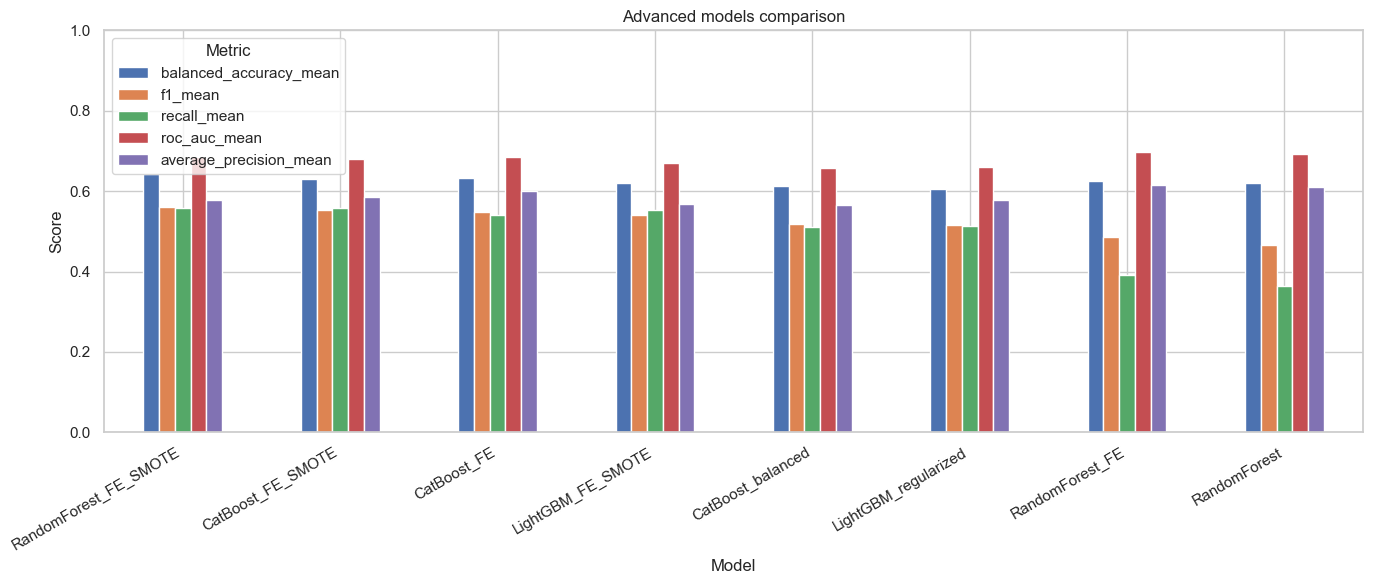

In [9]:
metrics_to_plot = [
    "balanced_accuracy_mean",
    "f1_mean",
    "recall_mean",
    "roc_auc_mean",
    "average_precision_mean"
]

comparison[metrics_to_plot].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Advanced models comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 10. Multi-metric model selection

In [10]:
selection_table = comparison[
    [
        "f1_mean",
        "recall_mean",
        "precision_mean",
        "roc_auc_mean",
        "balanced_accuracy_mean",
        "average_precision_mean"
    ]
].copy()

display(selection_table)

,f1_mean,recall_mean,precision_mean,roc_auc_mean,balanced_accuracy_mean,average_precision_mean
RandomForest_FE_SMOTE,0.5609,0.5586,0.5656,0.6854,0.6419,0.5780
CatBoost_FE_SMOTE,0.5519,0.5587,0.5476,0.6796,0.6313,0.5861
CatBoost_FE,0.5469,0.5411,0.5557,0.6855,0.6319,0.6000
LightGBM_FE_SMOTE,0.5413,0.5537,0.5303,0.6690,0.6201,0.5691
CatBoost_balanced,0.5194,0.5097,0.5333,0.6578,0.6125,0.5648
LightGBM_regularized,0.5164,0.5127,0.5216,0.6602,0.6065,0.5779
RandomForest_FE,0.4856,0.3924,0.6428,0.6978,0.6261,0.6151
RandomForest,0.4664,0.3630,0.6562,0.6936,0.6205,0.6101


## 11. Выбор кандидата для tuning

Выбираем модель с лучшим F1 на cross-validation.

Почему F1:

- в baseline recall класса `1` был слабым;
- нужно улучшить обнаружение положительного класса;
- F1 не позволяет максимизировать recall ценой полного падения precision.


In [11]:
best_cv_model_name = comparison.index[0]

print("Best model by CV F1:", best_cv_model_name)
display(selection_table.loc[[best_cv_model_name]])

Best model by CV F1: RandomForest_FE_SMOTE


,f1_mean,recall_mean,precision_mean,roc_auc_mean,balanced_accuracy_mean,average_precision_mean
RandomForest_FE_SMOTE,0.5609,0.5586,0.5656,0.6854,0.6419,0.5780


Модель RandomForest_FE_SMOTE была выбрана, так как обеспечивает наилучший баланс между precision и recall и максимизирует F1-score среди рассмотренных моделей.

## 12. Hyperparameter tuning

In [12]:
def build_search_space(model_name):
    if model_name == "RandomForest":
        base_model = models[model_name]
        param_distributions = {
            "model__n_estimators": [300, 500, 700],
            "model__max_depth": [None, 6, 10, 14],
            "model__min_samples_leaf": [1, 2, 4, 8],
            "model__max_features": ["sqrt", "log2", None]
        }

    elif model_name == "RandomForest_FE":
        base_model = models[model_name]
        param_distributions = {
            "model__n_estimators": [300, 500, 700],
            "model__max_depth": [None, 6, 10, 14],
            "model__min_samples_leaf": [1, 2, 4, 8],
            "model__max_features": ["sqrt", "log2", None]
        }

    elif model_name == "RandomForest_FE_SMOTE":
        base_model = models[model_name]
        param_distributions = {
            "model__n_estimators": [300, 500, 700],
            "model__max_depth": [None, 6, 10, 14],
            "model__min_samples_leaf": [1, 2, 4, 8],
            "model__max_features": ["sqrt", "log2", None],
            "smote__k_neighbors": [3, 5, 7]
        }

    elif model_name == "CatBoost_balanced":
        base_model = models[model_name]
        param_distributions = {
            "model__iterations": [800, 1000, 1200, 1500],
            "model__learning_rate": [0.02, 0.03, 0.05],
            "model__depth": [3, 4, 5, 6],
            "model__l2_leaf_reg": [3, 5, 7, 10]
        }

    elif model_name == "CatBoost_FE":
        base_model = models[model_name]
        param_distributions = {
            "model__iterations": [800, 1000, 1200, 1500],
            "model__learning_rate": [0.02, 0.03, 0.05],
            "model__depth": [3, 4, 5, 6],
            "model__l2_leaf_reg": [3, 5, 7, 10]
        }

    elif model_name == "CatBoost_FE_SMOTE":
        base_model = models[model_name]
        param_distributions = {
            "model__iterations": [700, 1000, 1200],
            "model__learning_rate": [0.02, 0.03, 0.05],
            "model__depth": [4, 5, 6],
            "model__l2_leaf_reg": [3, 5, 7],
            "smote__k_neighbors": [3, 5, 7]
        }

    elif model_name == "LightGBM_regularized":
        base_model = models[model_name]
        param_distributions = {
            "model__n_estimators": [500, 700, 1000],
            "model__learning_rate": [0.02, 0.03, 0.05],
            "model__num_leaves": [7, 15, 31],
            "model__min_child_samples": [20, 30, 50],
            "model__subsample": [0.7, 0.8, 1.0],
            "model__colsample_bytree": [0.7, 0.8, 1.0],
            "model__reg_lambda": [0.5, 1.0, 3.0]
        }

    elif model_name == "LightGBM_FE_SMOTE":
        base_model = models[model_name]
        param_distributions = {
            "model__n_estimators": [500, 700, 1000],
            "model__learning_rate": [0.02, 0.03, 0.05],
            "model__num_leaves": [7, 15, 31],
            "model__min_child_samples": [20, 30, 50],
            "model__subsample": [0.7, 0.8, 1.0],
            "model__colsample_bytree": [0.7, 0.8, 1.0],
            "model__reg_lambda": [0.5, 1.0, 3.0],
            "smote__k_neighbors": [3, 5, 7]
        }

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return base_model, param_distributions


base_model_for_tuning, param_distributions = build_search_space(best_cv_model_name)

search = RandomizedSearchCV(
    estimator=base_model_for_tuning,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="f1",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best params:")
print(search.best_params_)
print()
print(f"Best CV F1: {search.best_score_:.4f}")

tuned_model = search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params:
{'smote__k_neighbors': 3, 'model__n_estimators': 700, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': 6}

Best CV F1: 0.5585


## 13. Финальная оценка tuned model на test set

Теперь обучаем tuned model на всём train и оцениваем на test.

Это главный финальный результат модели при стандартном threshold = 0.5.

In [48]:
tuned_model.fit(X_train, y_train)

y_pred = tuned_model.predict(X_test)
y_proba = tuned_model.predict_proba(X_test)[:, 1]

test_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "average_precision": average_precision_score(y_test, y_proba)
}

test_metrics_df = pd.DataFrame(test_metrics, index=["Advanced_tuned_test"]).T
display(test_metrics_df)

print(classification_report(y_test, y_pred, zero_division=0))

joblib.dump(tuned_model, "models/best_model.pkl")

,Advanced_tuned_test
accuracy,0.6677
balanced_accuracy,0.6487
precision,0.5760
recall,0.5625
f1,0.5692
roc_auc,0.7020
average_precision,0.6393


              precision    recall  f1-score   support

           0       0.72      0.73      0.73       400
           1       0.58      0.56      0.57       256

    accuracy                           0.67       656
   macro avg       0.65      0.65      0.65       656
weighted avg       0.67      0.67      0.67       656



['models/best_model.pkl']

## 14. Baseline vs Advanced

Сравним baseline RandomForest из `02_baseline.ipynb` с финальной tuned model.

In [14]:
advanced_test_metrics = pd.Series(test_metrics, name="Advanced_tuned_test")

baseline_vs_advanced = pd.DataFrame([
    baseline_test_metrics,
    advanced_test_metrics
])

display(baseline_vs_advanced)

improvement = advanced_test_metrics - baseline_test_metrics
display(improvement.to_frame("absolute_improvement"))

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
Baseline_RF_test,0.6616,0.6037,0.6214,0.3398,0.4394,0.6607,NaN
Advanced_tuned_test,0.6677,0.6487,0.5760,0.5625,0.5692,0.7020,0.6393


,absolute_improvement
accuracy,0.0061
balanced_accuracy,0.0450
precision,-0.0454
recall,0.2227
f1,0.1298
roc_auc,0.0413
average_precision,NaN


## 15. Confusion Matrix

Матрица ошибок показывает, какие ошибки делает финальная модель.

Интерпретация:

- True 0 / Pred 0 — правильно нашли непригодную воду;
- True 0 / Pred 1 — ошибочно признали воду пригодной;
- True 1 / Pred 0 — ошибочно отвергли пригодную воду;
- True 1 / Pred 1 — правильно нашли пригодную воду.

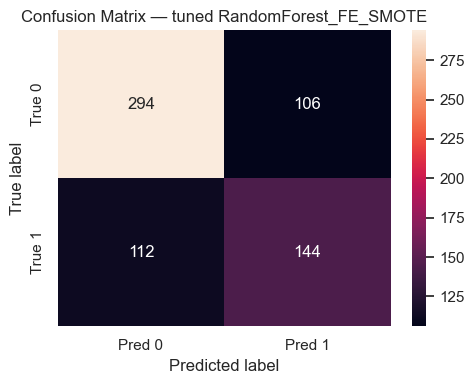

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["True 0", "True 1"]
)

plt.title(f"Confusion Matrix — tuned {best_cv_model_name}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

## 16. ROC и Precision-Recall curves

ROC-кривая показывает качество ранжирования.  
Precision-Recall curve полезна при дисбалансе классов.

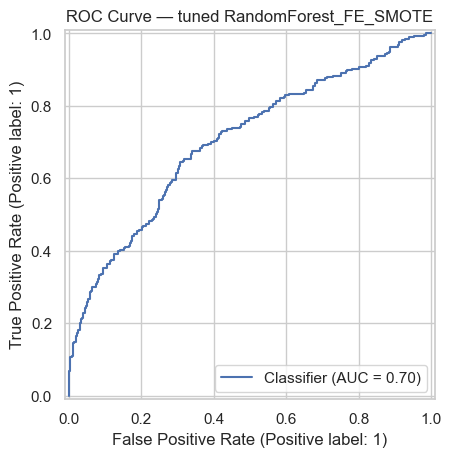

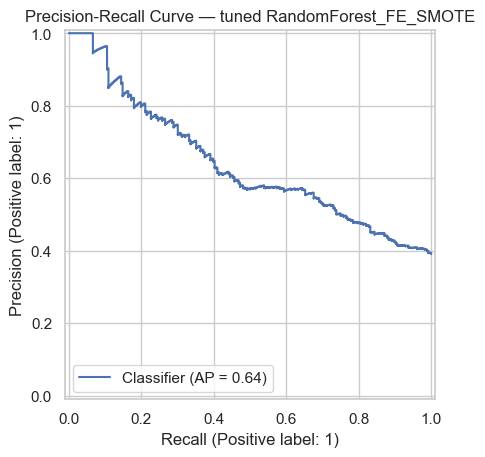

In [16]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title(f"ROC Curve — tuned {best_cv_model_name}")
plt.grid(True)
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title(f"Precision-Recall Curve — tuned {best_cv_model_name}")
plt.grid(True)
plt.show()

## 17. Threshold analysis

Этот блок является **exploratory**.

Важно:

- здесь мы анализируем threshold на test set;
- это нельзя использовать как честный способ выбора финального threshold;
- правильный вариант — подбирать threshold на validation set или через out-of-fold predictions.

Зачем:

- чтобы понять trade-off между precision и recall;
- чтобы показать, что модель можно настроить под разные бизнес-требования.

,threshold,precision,recall,f1
347,0.4857,0.5599,0.6758,0.6124
346,0.4855,0.5581,0.6758,0.6113
300,0.4773,0.5253,0.7305,0.6111
345,0.4855,0.5563,0.6758,0.6102
299,0.4773,0.5238,0.7305,0.6101
348,0.4859,0.5584,0.6719,0.6099
302,0.4777,0.5254,0.7266,0.6098
305,0.4783,0.5271,0.7227,0.6096
331,0.4830,0.5446,0.6914,0.6093
344,0.4854,0.5545,0.6758,0.6092


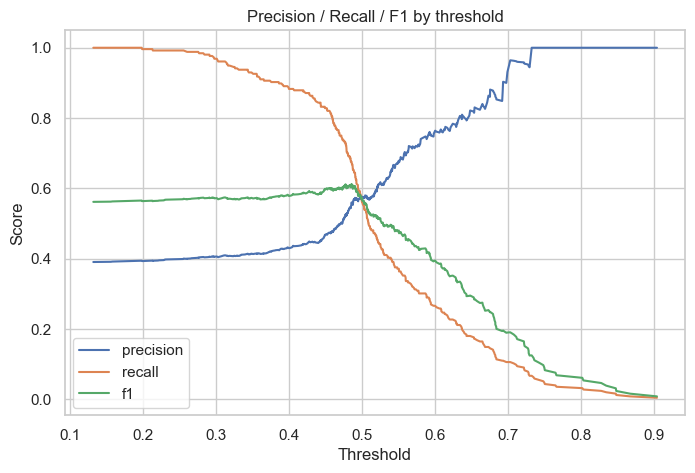

In [17]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

f1_scores = 2 * precision * recall / (precision + recall + 1e-12)

threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1],
    "f1": f1_scores[:-1]
})

display(threshold_df.sort_values("f1", ascending=False).head(10))

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="f1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 by threshold")
plt.legend()
plt.grid(True)
plt.show()

## 18. Error Analysis

Теперь посмотрим, где финальная модель ошибается.

Нас интересуют:

- False Negative: вода пригодна (`1`), но модель предсказала `0`;
- False Positive: вода непригодна (`0`), но модель предсказала `1`.

Это помогает понять слабые места модели.

In [18]:
errors = X_test.copy()
errors["y_true"] = y_test.values
errors["y_pred"] = y_pred
errors["y_proba"] = y_proba

false_negatives = errors[(errors["y_true"] == 1) & (errors["y_pred"] == 0)]
false_positives = errors[(errors["y_true"] == 0) & (errors["y_pred"] == 1)]
true_positives = errors[(errors["y_true"] == 1) & (errors["y_pred"] == 1)]
true_negatives = errors[(errors["y_true"] == 0) & (errors["y_pred"] == 0)]

print("False negatives:", false_negatives.shape[0])
print("False positives:", false_positives.shape[0])
print("True positives:", true_positives.shape[0])
print("True negatives:", true_negatives.shape[0])

False negatives: 112
False positives: 106
True positives: 144
True negatives: 294


## 19. Сравнение статистик ошибок

Сравним средние значения признаков для разных групп предсказаний.

In [19]:
groups_summary = pd.DataFrame({
    "false_negative_mean": false_negatives[X_test.columns].mean(),
    "false_positive_mean": false_positives[X_test.columns].mean(),
    "true_positive_mean": true_positives[X_test.columns].mean(),
    "true_negative_mean": true_negatives[X_test.columns].mean()
})

display(groups_summary)

,false_negative_mean,false_positive_mean,true_positive_mean,true_negative_mean
ph,6.6593,7.1802,7.1253,7.1128
Hardness,197.9873,196.4215,189.6561,197.6740
Solids,22999.0159,21924.4384,23277.8677,22175.2939
Chloramines,7.1445,7.3756,7.3159,6.9803
Sulfate,329.5624,334.0637,330.1129,335.2073
Conductivity,415.3929,413.1945,413.2891,426.0958
Organic_carbon,14.2215,14.5764,13.7018,14.5987
Trihalomethanes,67.7383,68.4297,67.8288,66.6864
Turbidity,3.8840,4.0354,3.9849,3.9024


## 20. Распределение вероятностей по группам ошибок

Посмотрим, насколько уверенно модель ошибается.

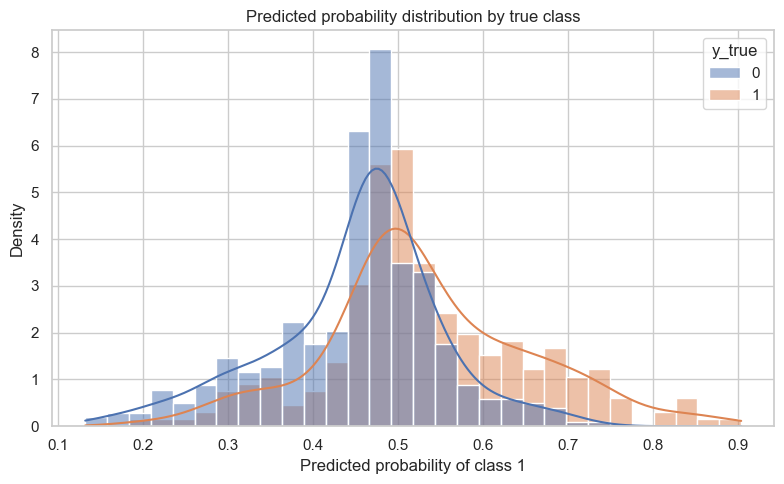

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=errors,
    x="y_proba",
    hue="y_true",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Predicted probability distribution by true class")
plt.xlabel("Predicted probability of class 1")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

Распределения вероятностей для классов существенно пересекаются, что объясняет ошибки классификации.

## 21. Интерпретация модели с использованием SHAP

SHAP values shape: (656, 21, 2)
X_test_processed shape: (656, 21)


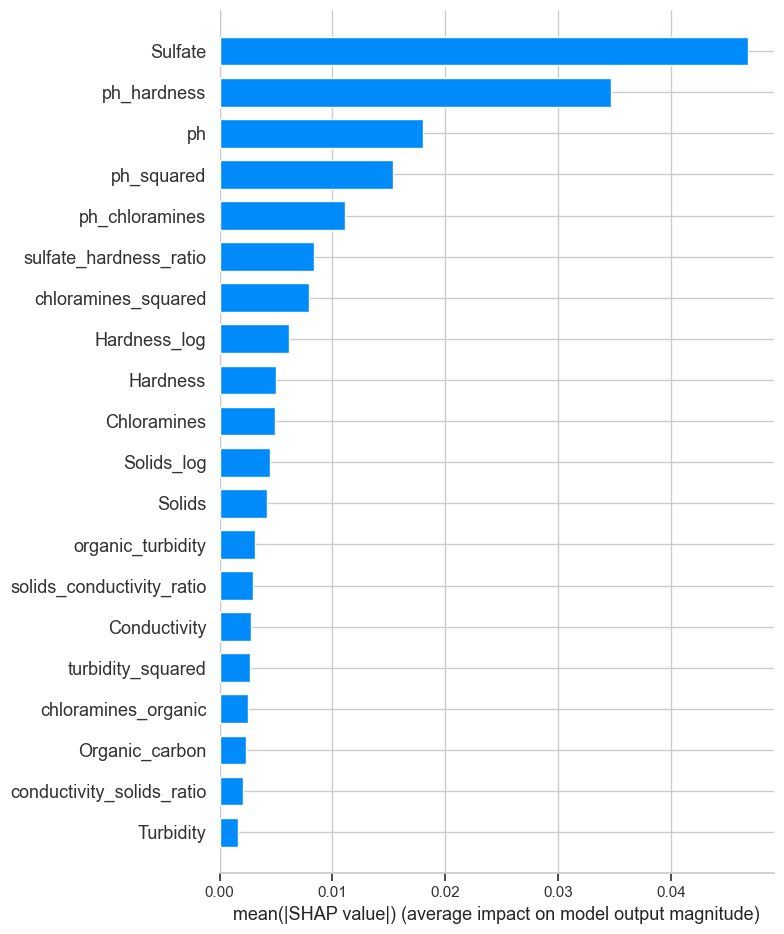

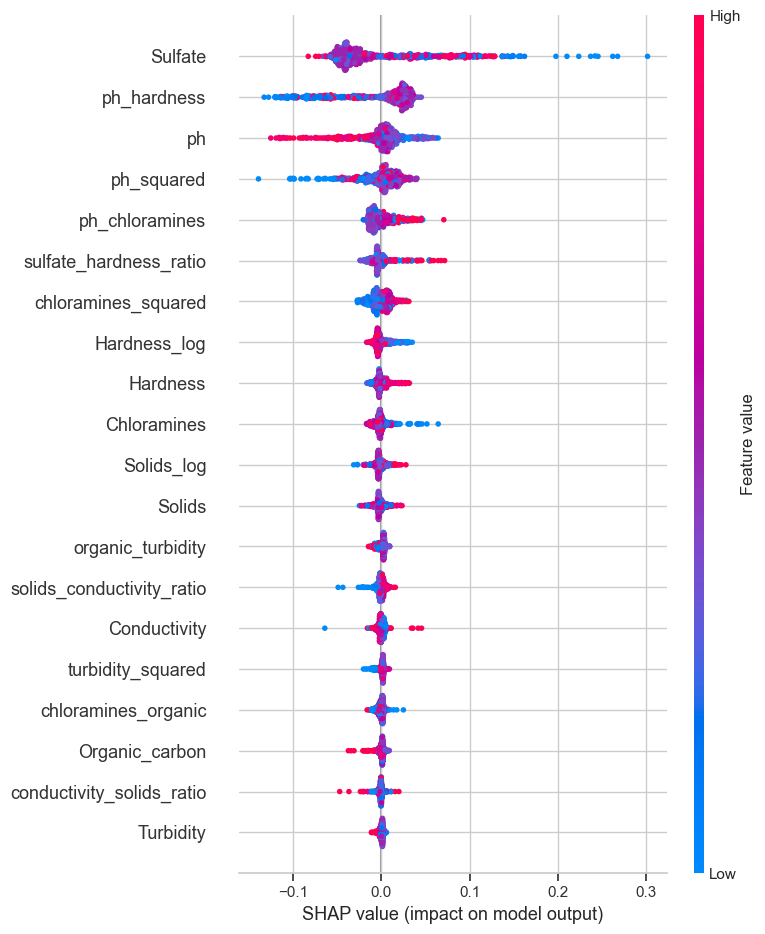

In [46]:
final_model = tuned_model.named_steps["model"]

X_test_fe = tuned_model.named_steps["features"].transform(X_test)
X_test_processed = tuned_model.named_steps["imputer"].transform(X_test_fe)

feature_names = X_test_fe.columns

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_processed)

print("SHAP values shape:", np.array(shap_values).shape)
print("X_test_processed shape:", X_test_processed.shape)

if isinstance(shap_values, list):
    shap_values_class_1 = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_class_1 = shap_values[:, :, 1]
else:
    shap_values_class_1 = shap_values

shap.summary_plot(
    shap_values_class_1,
    X_test_processed,
    plot_type="bar"
)

shap.summary_plot(
    shap_values_class_1,
    X_test_processed
)

## Общий вывод 

В ходе экспериментов были обучены и сравнены различные модели:
RandomForest, LightGBM, CatBoost, а также их версии с Feature Engineering и балансировкой классов (SMOTE).

Наилучший результат показала модель RandomForest с применением Feature Engineering и SMOTE.

Основные метрики на тестовой выборке:
- ROC-AUC: ~0.70
- F1-score: ~0.57
- Recall: ~0.56
- Balanced Accuracy: ~0.65

Это является улучшением по сравнению с baseline (F1 ~0.44, Recall ~0.34).

### Анализ качества модели:

Модель стала лучше обнаруживать положительный класс (пригодную для питья воду):
- True Positives: 144
- False Negatives: 112

Однако остаётся заметное количество ошибок:
- False Positives: 106

### Анализ ошибок модели показал:

Средние значения признаков для False Positives и False Negatives близки к значениям True классов.

Это подтверждает вывод из EDA: признаки слабо разделяют классы

Модель испытывает трудности в разделении классов, так как:
- распределения признаков сильно пересекаются
- отсутствуют выраженные закономерности
- корреляция с целевой переменной низкая

### Основные выводы:

1. Главный прирост качества был достигнут за счёт:
   - балансировки классов (SMOTE)
   - feature engineering

2. Смена модели (RandomForest / CatBoost / LightGBM)
   дала меньший эффект, чем работа с данными

3. Задача является сложной из-за слабой информативности признаков

4. Дальнейший рост качества возможен за счёт:
   - более сложного feature engineering
   - дополнительного сбора данных